# 🌫️ PM2.5 Maroc — Modeling & Forecasting (H+1 → H+24)

**Objectif :** Comparer toutes les approches de forecasting PM2.5 heure par heure.

| # | Modèle | Type |
|---|--------|------|
| B1 | Persistence Model | Baseline |
| B2 | Moving Average | Baseline |
| M1 | Linear Regression | ML |
| M2 | Random Forest | ML |
| M3 | Extra Trees | ML |
| M4 | XGBoost | Boosting |
| M5 | LightGBM | Boosting |
| M6 | CatBoost | Boosting |
| M7 | GRU | Deep Learning |

## 0. Configuration & Imports

In [ ]:
# !pip install catboost

In [ ]:
import warnings, os, gc, time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import lightgbm as lgb
import xgboost as xgb
from catboost import CatBoostRegressor, Pool

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", "{:.4f}".format)

# ─── Paths ─────────────────────────────────────────────────────────────────────
FE_DIR  = Path(r"E:\pipeline\test2\feature_engineering_outputs")

OUT_DIR = Path(r"E:\pipeline\test2\modeling_outputs")
OUT_DIR.mkdir(parents=True, exist_ok=True)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}")

# ─── Horizons ──────────────────────────────────────────────────────────────────
HORIZONS = list(range(1, 25))   # h1 → h24
TARGET_H1  = "target24_h1"

SEED = 42
np.random.seed(SEED)

Device: cpu


## 1. Chargement & Split Temporel

In [ ]:
df = pd.read_csv(
    FE_DIR / "pm25_supervised_h1_h24.csv", 
    engine="pyarrow", 
    dtype_backend="pyarrow" 
)
df["datetime"] = pd.to_datetime(df["datetime"])
df = df.sort_values(["city", "datetime"]).reset_index(drop=True)

print(f"Shape: {df.shape}")
print(f"Période: {df['datetime'].min()} → {df['datetime'].max()}")
print(f"Villes: {df['city'].nunique()}")

Shape: (1315150, 118)
Période: 2023-06-09 00:00:00 → 2026-06-08 22:00:00
Villes: 50


In [4]:
# ─── Features safe (sans fuite temporelle) ────────────────────────────────────
safe_features_path = FE_DIR / "safe_feature_columns.txt"
with open(safe_features_path) as f:
    SAFE_FEATURES = [line.strip() for line in f if line.strip()]

# Encoder city → int (pour LR/RF/ET)
le = LabelEncoder()
df["city_enc"] = le.fit_transform(df["city"])

FEAT_NUM = [c for c in SAFE_FEATURES if c != "city"] + ["city_enc"]
FEAT_NUM = [c for c in FEAT_NUM if c in df.columns]

TARGET_COLS = [f"target24_h{h}" for h in HORIZONS]

print(f"Features numériques: {len(FEAT_NUM)}")
print(FEAT_NUM)

Features numériques: 66
['lat', 'lon', 'hour', 'dayofweek', 'month', 'day', 'weekofyear', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos', 'pm25_lag_1h', 'pm25_lag_2h', 'pm25_lag_3h', 'pm25_lag_6h', 'pm25_lag_12h', 'pm25_lag_24h', 'pm25_lag_48h', 'pm25_lag_72h', 'pm25_lag_168h', 'pm25_lag_336h', 'roll_mean_3h', 'roll_std_3h', 'roll_min_3h', 'roll_max_3h', 'roll_mean_6h', 'roll_std_6h', 'roll_min_6h', 'roll_max_6h', 'roll_mean_12h', 'roll_std_12h', 'roll_min_12h', 'roll_max_12h', 'roll_mean_24h', 'roll_std_24h', 'roll_min_24h', 'roll_max_24h', 'roll_mean_48h', 'roll_std_48h', 'roll_min_48h', 'roll_max_48h', 'roll_mean_72h', 'roll_std_72h', 'roll_min_72h', 'roll_max_72h', 'roll_mean_168h', 'roll_std_168h', 'roll_min_168h', 'roll_max_168h', 'temp_change_1h', 'humidity_change_1h', 'pm25_change_1h', 'pm25_ewm_6h', 'pm25_ewm_24h', 'pm25_city_hour_mean', 'pm25_city_dow_mean', 'pm25_city_month_mean', 'temp_humidity', 'temp_wind', 'humidity_wind', 'pm25_change_3h', 'pm25_

In [5]:
# ─── Split temporel strict (80/10/10) ─────────────────────────────────────────
# On split sur les timestamps uniques pour éviter le data leakage
dates = df["datetime"].sort_values().unique()
n = len(dates)
train_end = dates[int(n * 0.80)]
val_end   = dates[int(n * 0.90)]

train_mask = df["datetime"] <  train_end
val_mask   = (df["datetime"] >= train_end) & (df["datetime"] < val_end)
test_mask  = df["datetime"] >= val_end

df_train = df[train_mask].copy()
df_val   = df[val_mask].copy()
df_test  = df[test_mask].copy()

print(f"Train : {len(df_train):>7,} rows  ({df_train['datetime'].min().date()} → {df_train['datetime'].max().date()})")
print(f"Val   : {len(df_val):>7,} rows  ({df_val['datetime'].min().date()} → {df_val['datetime'].max().date()})")
print(f"Test  : {len(df_test):>7,} rows  ({df_test['datetime'].min().date()} → {df_test['datetime'].max().date()})")

Train : 1,052,100 rows  (2023-06-09 → 2025-11-01)
Val   : 131,500 rows  (2025-11-01 → 2026-02-19)
Test  : 131,550 rows  (2026-02-19 → 2026-06-08)


In [6]:
# ─── Utilitaires d'évaluation ─────────────────────────────────────────────────
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def smape(y_true, y_pred):
    """Symmetric MAPE — moins sensible aux 0."""
    num = np.abs(y_pred - y_true)
    den = (np.abs(y_true) + np.abs(y_pred)) / 2 + 1e-8
    return np.mean(num / den) * 100

def evaluate(name, y_true, y_pred):
    """Retourne un dict de métriques."""
    mask = ~(np.isnan(y_true) | np.isnan(y_pred))
    y_true, y_pred = y_true[mask], y_pred[mask]
    return {
        "Model": name,
        "MAE":   round(mean_absolute_error(y_true, y_pred), 4),
        "RMSE":  round(rmse(y_true, y_pred), 4),
        "SMAPE": round(smape(y_true, y_pred), 4),
        "R2":    round(r2_score(y_true, y_pred), 4),
        "N":     int(mask.sum()),
    }

# Dictionnaire global pour stocker tous les résultats
RESULTS = []

---
## B1 — Baseline : Persistence Model
> **Prédiction = dernière valeur observée** (pm25_lag_Xh)  
> Pour horizon h, on utilise pm25_lag_1h comme proxy de "dernière valeur connue".

In [7]:
results_persistence = []

for h in HORIZONS:
    target_col = f"target24_h{h}"
    # La dernière valeur connue = pm25_lag_1h (valeur à t-1)
    # (on ne peut pas utiliser pm2_5 directement car ce serait leakage)
    y_true = df_test[target_col].values
    y_pred = df_test["pm25_lag_1h"].values   # persistence naïve

    mask = ~(np.isnan(y_true) | np.isnan(y_pred))
    results_persistence.append({
        "Horizon": h,
        "MAE":  round(mean_absolute_error(y_true[mask], y_pred[mask]), 3),
        "RMSE": round(rmse(y_true[mask], y_pred[mask]), 3),
    })

df_persistence = pd.DataFrame(results_persistence)

# Store h1 global result
y_true_h1 = df_test[TARGET_H1].dropna().values
y_pred_h1 = df_test.loc[df_test[TARGET_H1].notna(), "pm25_lag_1h"].values
RESULTS.append(evaluate("B1 – Persistence", y_true_h1, y_pred_h1))

display(df_persistence)
print(f"\n→ MAE moyen H1–H24 : {df_persistence['MAE'].mean():.3f}")

,Horizon,MAE,RMSE
0,1,1.2350,2.2000
1,2,1.6480,2.8950
2,3,1.9960,3.4700
3,4,2.2880,3.9510
4,5,2.5390,4.3540
5,6,2.7500,4.6890
6,7,2.9300,4.9660
7,8,3.0830,5.2010
8,9,3.2120,5.4000
9,10,3.3210,5.5660



→ MAE moyen H1–H24 : 3.101


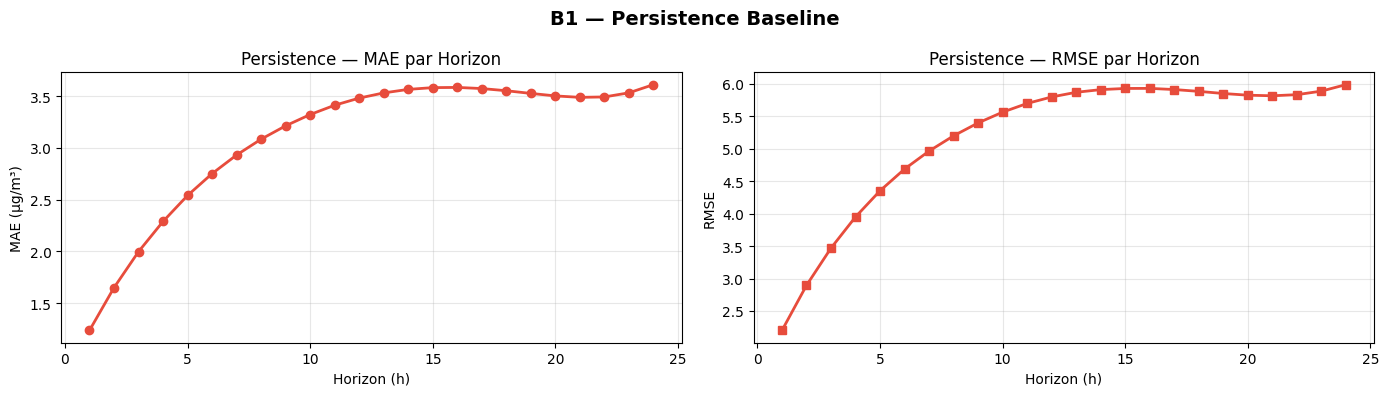

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(df_persistence["Horizon"], df_persistence["MAE"], "o-", color="#E74C3C", lw=2)
axes[0].set(title="Persistence — MAE par Horizon", xlabel="Horizon (h)", ylabel="MAE (µg/m³)")
axes[0].grid(alpha=0.3)

axes[1].plot(df_persistence["Horizon"], df_persistence["RMSE"], "s-", color="#E74C3C", lw=2)
axes[1].set(title="Persistence — RMSE par Horizon", xlabel="Horizon (h)", ylabel="RMSE")
axes[1].grid(alpha=0.3)

plt.suptitle("B1 — Persistence Baseline", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(OUT_DIR / "b1_persistence.png", dpi=120, bbox_inches="tight")
plt.show()

---
## B2 — Baseline : Moving Average
> **Prédiction = moyenne glissante des 6 dernières heures** (roll_mean_6h)

In [9]:
results_ma = []

for h in HORIZONS:
    target_col = f"target24_h{h}"
    y_true = df_test[target_col].values
    y_pred = df_test["roll_mean_6h"].values    # moving average 6h

    mask = ~(np.isnan(y_true) | np.isnan(y_pred))
    results_ma.append({
        "Horizon": h,
        "MAE":  round(mean_absolute_error(y_true[mask], y_pred[mask]), 3),
        "RMSE": round(rmse(y_true[mask], y_pred[mask]), 3),
    })

df_ma = pd.DataFrame(results_ma)

y_true_h1 = df_test[TARGET_H1].dropna().values
y_pred_h1 = df_test.loc[df_test[TARGET_H1].notna(), "roll_mean_6h"].values
RESULTS.append(evaluate("B2 – Moving Avg 6h", y_true_h1, y_pred_h1))

display(df_ma)
print(f"\n→ MAE moyen H1–H24 : {df_ma['MAE'].mean():.3f}")

,Horizon,MAE,RMSE
0,1,1.9340,3.3240
1,2,2.2160,3.7880
2,3,2.4560,4.1780
3,4,2.6610,4.5070
4,5,2.8360,4.7830
5,6,2.9820,5.0130
6,7,3.1040,5.2030
7,8,3.2050,5.3580
8,9,3.2850,5.4800
9,10,3.3470,5.5700



→ MAE moyen H1–H24 : 3.191


---
## M1 — Linear Regression (Ridge)
> Modèle unique par horizon, features numériques safe.

In [10]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_raw = df_train[FEAT_NUM].fillna(0).values
X_val_raw   = df_val[FEAT_NUM].fillna(0).values
X_test_raw  = df_test[FEAT_NUM].fillna(0).values

X_train_sc = scaler.fit_transform(X_train_raw)
X_val_sc   = scaler.transform(X_val_raw)
X_test_sc  = scaler.transform(X_test_raw)

results_lr = []

for h in HORIZONS:
    target_col = f"target24_h{h}"
    mask_train = df_train[target_col].notna()
    mask_test  = df_test[target_col].notna()

    model = Ridge(alpha=10, random_state=SEED)
    model.fit(X_train_sc[mask_train], df_train.loc[mask_train, target_col])

    y_pred = model.predict(X_test_sc[mask_test])
    y_true = df_test.loc[mask_test, target_col].values

    results_lr.append({
        "Horizon": h,
        "MAE":  round(mean_absolute_error(y_true, y_pred), 3),
        "RMSE": round(rmse(y_true, y_pred), 3),
    })

df_lr = pd.DataFrame(results_lr)

# Store h1 result
mask_test_h1 = df_test[TARGET_H1].notna()
model_h1 = Ridge(alpha=10, random_state=SEED)
mask_train_h1 = df_train[TARGET_H1].notna()
model_h1.fit(X_train_sc[mask_train_h1], df_train.loc[mask_train_h1, TARGET_H1])
y_pred_h1 = model_h1.predict(X_test_sc[mask_test_h1])
RESULTS.append(evaluate("M1 – Ridge", df_test.loc[mask_test_h1, TARGET_H1].values, y_pred_h1))

display(df_lr)
print(f"\n→ MAE moyen H1–H24 : {df_lr['MAE'].mean():.3f}")

,Horizon,MAE,RMSE
0,1,0.6520,1.1850
1,2,1.1250,1.9710
2,3,1.4910,2.5660
3,4,1.7840,3.0340
4,5,2.0150,3.4030
5,6,2.2030,3.6990
6,7,2.3550,3.9310
7,8,2.4800,4.1150
8,9,2.5800,4.2650
9,10,2.6590,4.3910



→ MAE moyen H1–H24 : 2.571


---
## M2 — Random Forest
> Évaluation rapide sur H+1 et H+12 pour économiser la RAM.

In [12]:
results_rf = []

RF_PARAMS = dict(
    n_estimators=100,
    max_depth=10,
    min_samples_leaf=10,
    max_features=0.5,
    n_jobs=-1,
    random_state=SEED,
)

# Seulement 4 horizons représentatifs au lieu de 24
HORIZONS_RF = [1, 6, 12, 24]

for h in HORIZONS_RF:
    target_col = f"target24_h{h}"
    mask_tr = df_train[target_col].notna()
    mask_te = df_test[target_col].notna()

    # Subsample train à 20% pour accélérer (toujours ~70k lignes)
    idx_sample = df_train[mask_tr].sample(frac=0.2, random_state=SEED).index
    mask_sample = df_train.index.isin(idx_sample)

    rf = RandomForestRegressor(**RF_PARAMS)
    rf.fit(X_train_raw[mask_sample], df_train.loc[mask_sample, target_col])

    y_pred = rf.predict(X_test_raw[mask_te])
    y_true = df_test.loc[mask_te, target_col].values

    results_rf.append({
        "Horizon": h,
        "MAE":  round(mean_absolute_error(y_true, y_pred), 3),
        "RMSE": round(rmse(y_true, y_pred), 3),
    })

    if h == 1:
        RESULTS.append(evaluate("M2 – Random Forest", y_true, y_pred))
        fi_rf = pd.Series(rf.feature_importances_, index=FEAT_NUM).sort_values(ascending=False)

    del rf; gc.collect()
    print(f"✓ H+{h} done")

# Interpoler les horizons manquants pour la courbe comparative
df_rf = pd.DataFrame(results_rf)
display(df_rf)
print(f"\n→ MAE moyen H1/H6/H12/H24 : {df_rf['MAE'].mean():.3f}")

✓ H+1 done
✓ H+6 done
✓ H+12 done
✓ H+24 done


,Horizon,MAE,RMSE
0,1,0.6770,1.4350
1,6,2.2150,3.8130
2,12,2.7510,4.5980
3,24,3.1730,5.0760



→ MAE moyen H1/H6/H12/H24 : 2.204


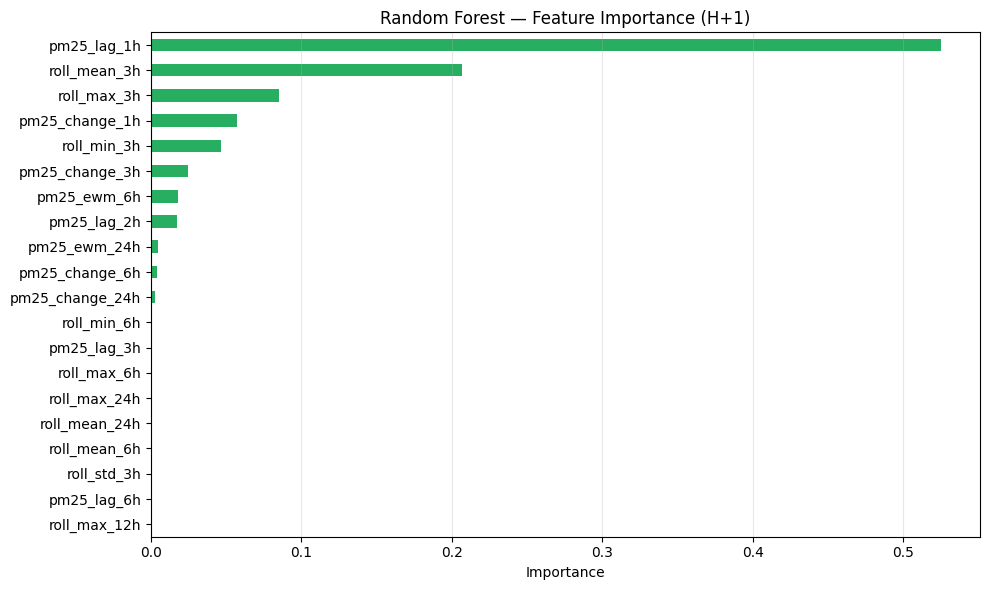

In [13]:
# ─── Feature importance RF (top 20) ───────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))
fi_rf.head(20).sort_values().plot.barh(ax=ax, color="#27AE60")
ax.set(title="Random Forest — Feature Importance (H+1)", xlabel="Importance")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.savefig(OUT_DIR / "m2_rf_feature_importance.png", dpi=120, bbox_inches="tight")
plt.show()

---
## M3 — Extra Trees Regressor

In [14]:
results_et = []

ET_PARAMS = dict(
    n_estimators=100,
    max_depth=10,
    min_samples_leaf=10,
    max_features=0.5,
    n_jobs=-1,
    random_state=SEED,
)

HORIZONS_ET = [1, 6, 12, 24]  # mêmes horizons que RF

for h in HORIZONS_ET:
    target_col = f"target24_h{h}"
    mask_tr = df_train[target_col].notna()
    mask_te = df_test[target_col].notna()

    # Même subsample 20% que RF
    idx_sample = df_train[mask_tr].sample(frac=0.2, random_state=SEED).index
    mask_sample = df_train.index.isin(idx_sample)

    et = ExtraTreesRegressor(**ET_PARAMS)
    et.fit(X_train_raw[mask_sample], df_train.loc[mask_sample, target_col])

    y_pred = et.predict(X_test_raw[mask_te])
    y_true = df_test.loc[mask_te, target_col].values

    results_et.append({
        "Horizon": h,
        "MAE":  round(mean_absolute_error(y_true, y_pred), 3),
        "RMSE": round(rmse(y_true, y_pred), 3),
    })

    if h == 1:
        RESULTS.append(evaluate("M3 – Extra Trees", y_true, y_pred))
        fi_et = pd.Series(et.feature_importances_, index=FEAT_NUM).sort_values(ascending=False)

    del et; gc.collect()
    print(f"✓ H+{h} done")

df_et = pd.DataFrame(results_et)
display(df_et)
print(f"\n→ MAE moyen H1/H6/H12/H24 : {df_et['MAE'].mean():.3f}")

✓ H+1 done
✓ H+6 done
✓ H+12 done
✓ H+24 done


,Horizon,MAE,RMSE
0,1,0.8810,1.6960
1,6,2.3220,3.9300
2,12,2.8280,4.6770
3,24,3.2180,5.1250



→ MAE moyen H1/H6/H12/H24 : 2.312


---
## M4 — XGBoost
> Multi-output : un modèle par horizon avec early stopping sur val.

In [15]:
results_xgb = []
fi_xgb_dict = {}

XGB_PARAMS = dict(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=7,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=5,
    reg_alpha=0.1,
    reg_lambda=1.0,
    tree_method="hist",
    random_state=SEED,
    n_jobs=-1,
    verbosity=0,
)

for h in HORIZONS:
    target_col = f"target24_h{h}"
    mask_tr = df_train[target_col].notna()
    mask_va = df_val[target_col].notna()
    mask_te = df_test[target_col].notna()

    model = xgb.XGBRegressor(**XGB_PARAMS, early_stopping_rounds=50)
    model.fit(
        X_train_raw[mask_tr], df_train.loc[mask_tr, target_col],
        eval_set=[(X_val_raw[mask_va], df_val.loc[mask_va, target_col])],
        verbose=False,
    )

    y_pred = model.predict(X_test_raw[mask_te])
    y_true = df_test.loc[mask_te, target_col].values

    results_xgb.append({
        "Horizon": h,
        "MAE":  round(mean_absolute_error(y_true, y_pred), 3),
        "RMSE": round(rmse(y_true, y_pred), 3),
        "best_iter": model.best_iteration,
    })

    if h == 1:
        RESULTS.append(evaluate("M4 – XGBoost", y_true, y_pred))
        fi_xgb = pd.Series(model.feature_importances_, index=FEAT_NUM).sort_values(ascending=False)
        xgb_h1_preds = (y_true, y_pred)

    del model; gc.collect()

df_xgb = pd.DataFrame(results_xgb)
display(df_xgb)
print(f"\n→ MAE moyen H1–H24 : {df_xgb['MAE'].mean():.3f}")

,Horizon,MAE,RMSE,best_iter
0,1,0.6620,1.5000,998
1,2,1.0960,2.1300,759
2,3,1.4410,2.6510,964
3,4,1.7100,3.0780,689
4,5,1.9190,3.3890,523
5,6,2.0950,3.6440,434
6,7,2.2430,3.8800,293
7,8,2.3600,4.0560,238
8,9,2.4590,4.1950,201
9,10,2.5500,4.3310,253



→ MAE moyen H1–H24 : 2.485


---
## M5 — LightGBM
> Très rapide, gère nativement les NaN.

In [ ]:
results_lgb = []

LGB_PARAMS = dict(
    n_estimators=1000,
    learning_rate=0.05,
    num_leaves=127,
    max_depth=-1,
    min_child_samples=20,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    n_jobs=-1,
    random_state=SEED,
    verbosity=-1,
)

# ── Vérifier quelles colonnes posent problème ────────────────────────────────
print("Colonnes non-numériques dans FEAT_NUM:")
print(df_train[FEAT_NUM].select_dtypes(exclude=[np.number]).columns.tolist())

# ── Fix : exclure city string, garder city_enc ───────────────────────────────
FEAT_NUM_LGB = [c for c in FEAT_NUM if c != "city" and c in df_train.columns]

X_tr_lgb = df_train[FEAT_NUM_LGB].astype(float).values.astype(np.float32)
X_va_lgb = df_val[FEAT_NUM_LGB].astype(float).values.astype(np.float32)
X_te_lgb = df_test[FEAT_NUM_LGB].astype(float).values.astype(np.float32)

print(f"Features LGB: {len(FEAT_NUM_LGB)}")
print(f"Shape train: {X_tr_lgb.shape}")

for h in HORIZONS:
    target_col = f"target24_h{h}"
    mask_tr = df_train[target_col].notna().values
    mask_va = df_val[target_col].notna().values
    mask_te = df_test[target_col].notna().values

    cb_train = lgb.Dataset(X_tr_lgb[mask_tr], label=df_train.loc[mask_tr, target_col].values.astype(np.float32), free_raw_data=False)
    cb_val   = lgb.Dataset(X_va_lgb[mask_va], label=df_val.loc[mask_va, target_col].values.astype(np.float32), reference=cb_train, free_raw_data=False)

    model = lgb.train(
        LGB_PARAMS,
        cb_train,
        valid_sets=[cb_val],
        callbacks=[
            lgb.early_stopping(stopping_rounds=50, verbose=False),
            lgb.log_evaluation(period=-1),
        ],
    )

    y_pred = model.predict(X_te_lgb[mask_te])
    y_true = df_test.loc[mask_te, target_col].values.astype(np.float32)

    results_lgb.append({
        "Horizon": h,
        "MAE":      round(mean_absolute_error(y_true, y_pred), 3),
        "RMSE":     round(rmse(y_true, y_pred), 3),
        "best_iter": model.best_iteration,
    })

    if h == 1:
        RESULTS.append(evaluate("M5 – LightGBM", y_true, y_pred))
        fi_lgb = pd.Series(
            model.feature_importance(importance_type="gain"),
            index=FEAT_NUM_LGB
        ).sort_values(ascending=False)
        lgb_h1_preds = (y_true, y_pred)

    del model, cb_train, cb_val; gc.collect()
    print(f"✓ H+{h} done")

df_lgb = pd.DataFrame(results_lgb)
display(df_lgb)
print(f"\n→ MAE moyen H1–H24 : {df_lgb['MAE'].mean():.3f}")

Colonnes non-numériques dans FEAT_NUM:
[]
Features LGB: 66
Shape train: (1052100, 66)
✓ H+1 done
✓ H+2 done
✓ H+3 done
✓ H+4 done
✓ H+5 done
✓ H+6 done
✓ H+7 done
✓ H+8 done
✓ H+9 done
✓ H+10 done
✓ H+11 done
✓ H+12 done
✓ H+13 done
✓ H+14 done
✓ H+15 done
✓ H+16 done
✓ H+17 done
✓ H+18 done
✓ H+19 done
✓ H+20 done
✓ H+21 done
✓ H+22 done
✓ H+23 done
✓ H+24 done


,Horizon,MAE,RMSE,best_iter
0,1,0.6450,1.3250,996
1,2,1.0900,2.0410,990
2,3,1.4280,2.5880,591
3,4,1.7070,3.0390,629
4,5,1.9210,3.3780,470
5,6,2.1060,3.6760,406
6,7,2.2510,3.8800,287
7,8,2.3710,4.0570,225
8,9,2.4930,4.2330,262
9,10,2.5650,4.3370,207



→ MAE moyen H1–H24 : 2.513


---
## M6 — CatBoost
> Gère la feature catégorielle `city` nativement (pas d'encodage nécessaire).

In [17]:
results_cb = []

# Features avec city en string pour CatBoost
FEAT_CB = [c for c in SAFE_FEATURES if c in df.columns]   # inclut city string
CAT_FEATURES_CB = ["city"] if "city" in FEAT_CB else []

CB_PARAMS = dict(
    iterations=1000,
    learning_rate=0.05,
    depth=7,
    l2_leaf_reg=3.0,
    loss_function="RMSE",
    random_seed=SEED,
    verbose=0,
    task_type="GPU" if DEVICE == "cuda" else "CPU",
    early_stopping_rounds=50,
)

for h in HORIZONS:
    target_col = f"target24_h{h}"
    mask_tr = df_train[target_col].notna()
    mask_va = df_val[target_col].notna()
    mask_te = df_test[target_col].notna()

    pool_tr = Pool(
        df_train.loc[mask_tr, FEAT_CB].fillna(0),
        label=df_train.loc[mask_tr, target_col],
        cat_features=CAT_FEATURES_CB,
    )
    pool_va = Pool(
        df_val.loc[mask_va, FEAT_CB].fillna(0),
        label=df_val.loc[mask_va, target_col],
        cat_features=CAT_FEATURES_CB,
    )
    pool_te = Pool(
        df_test.loc[mask_te, FEAT_CB].fillna(0),
        cat_features=CAT_FEATURES_CB,
    )

    model = CatBoostRegressor(**CB_PARAMS)
    model.fit(pool_tr, eval_set=pool_va)

    y_pred = model.predict(pool_te)
    y_true = df_test.loc[mask_te, target_col].values

    results_cb.append({
        "Horizon": h,
        "MAE":  round(mean_absolute_error(y_true, y_pred), 3),
        "RMSE": round(rmse(y_true, y_pred), 3),
        "best_iter": model.get_best_iteration(),
    })

    if h == 1:
        RESULTS.append(evaluate("M6 – CatBoost", y_true, y_pred))
        fi_cb = pd.Series(
            model.get_feature_importance(),
            index=FEAT_CB
        ).sort_values(ascending=False)

    del model, pool_tr, pool_va, pool_te; gc.collect()

df_cb = pd.DataFrame(results_cb)
display(df_cb)
print(f"\n→ MAE moyen H1–H24 : {df_cb['MAE'].mean():.3f}")

,Horizon,MAE,RMSE,best_iter
0,1,0.6430,1.3590,999
1,2,1.0820,2.0350,999
2,3,1.4200,2.5730,999
3,4,1.6900,3.0000,999
4,5,1.9100,3.3490,999
5,6,2.0970,3.6340,741
6,7,2.2380,3.8430,825
7,8,2.3680,4.0520,774
8,9,2.4710,4.2050,553
9,10,2.5590,4.3130,560



→ MAE moyen H1–H24 : 2.481


---
## M7 — GRU (Gated Recurrent Unit)
> Séquence de 24h → prédiction 24 horizons simultanément.  
> **RAM-friendly** : petite architecture, batch size modéré.

In [18]:
# ─── Paramètres GRU ────────────────────────────────────────────────────────────
SEQ_LEN    = 24       # 24 heures de contexte
BATCH_SIZE = 512      # réduire si OOM
N_EPOCHS   = 30
GRU_HIDDEN = 64       # réduit pour économiser la RAM
GRU_LAYERS = 2
DROPOUT    = 0.2
LR_GRU     = 3e-4

# Features pour GRU (numériques uniquement)
FEAT_GRU = [c for c in FEAT_NUM if c != "city_enc"] + ["city_enc"]
FEAT_GRU = [c for c in FEAT_GRU if c in df.columns]

print(f"GRU features: {len(FEAT_GRU)}")
print(f"Device: {DEVICE}")

GRU features: 66
Device: cpu


In [19]:
# ─── Dataset PyTorch ──────────────────────────────────────────────────────────
class PM25Dataset(Dataset):
    """
    Pour chaque ville séparément, on construit des séquences de SEQ_LEN heures.
    X : (SEQ_LEN, n_features)  → séquence passée
    y : (24,)                  → cibles h1..h24
    """
    def __init__(self, data, feat_cols, target_cols, seq_len):
        self.seq_len = seq_len
        self.X_list, self.y_list = [], []

        for city, g in data.groupby("city"):
            g = g.sort_values("datetime")
            X_arr = g[feat_cols].fillna(0).values.astype(np.float32)
            y_arr = g[target_cols].fillna(-1).values.astype(np.float32)

            for i in range(seq_len, len(g)):
                # Cible valide : au moins h1 disponible
                if y_arr[i, 0] < 0:
                    continue
                self.X_list.append(X_arr[i - seq_len : i])
                self.y_list.append(y_arr[i])

        self.X = np.stack(self.X_list, axis=0)
        self.y = np.stack(self.y_list, axis=0)
        # Remplacer les NaN targets par la valeur h1 (imputation simple)
        for col_i in range(self.y.shape[1]):
            bad = self.y[:, col_i] < 0
            self.y[bad, col_i] = self.y[bad, 0]

    def __len__(self):  return len(self.X)
    def __getitem__(self, idx):
        return torch.tensor(self.X[idx]), torch.tensor(self.y[idx])


# Normalisation globale sur train
feat_mean = df_train[FEAT_GRU].fillna(0).mean()
feat_std  = df_train[FEAT_GRU].fillna(0).std().replace(0, 1)

df_train_norm = df_train.copy()
df_val_norm   = df_val.copy()
df_test_norm  = df_test.copy()

for c in FEAT_GRU:
    df_train_norm[c] = (df_train[c] - feat_mean[c]) / feat_std[c]
    df_val_norm[c]   = (df_val[c]   - feat_mean[c]) / feat_std[c]
    df_test_norm[c]  = (df_test[c]  - feat_mean[c]) / feat_std[c]

print("Création des datasets...")
ds_train = PM25Dataset(df_train_norm, FEAT_GRU, TARGET_COLS, SEQ_LEN)
ds_val   = PM25Dataset(df_val_norm,   FEAT_GRU, TARGET_COLS, SEQ_LEN)
ds_test  = PM25Dataset(df_test_norm,  FEAT_GRU, TARGET_COLS, SEQ_LEN)

dl_train = DataLoader(ds_train, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0, pin_memory=True)
dl_val   = DataLoader(ds_val,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
dl_test  = DataLoader(ds_test,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"Train batches: {len(dl_train)} | Val: {len(dl_val)} | Test: {len(dl_test)}")

Création des datasets...
Train batches: 2053 | Val: 255 | Test: 255


In [20]:
# ─── Architecture GRU ─────────────────────────────────────────────────────────
class GRUForecaster(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size, dropout):
        super().__init__()
        self.gru = nn.GRU(
            input_size, hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        self.norm = nn.LayerNorm(hidden_size)
        self.head = nn.Sequential(
            nn.Linear(hidden_size, hidden_size // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_size // 2, output_size),
        )

    def forward(self, x):
        out, _ = self.gru(x)          # (B, SEQ, H)
        last    = self.norm(out[:, -1, :])   # dernier pas de temps
        return self.head(last)        # (B, 24)


gru_model = GRUForecaster(
    input_size  = len(FEAT_GRU),
    hidden_size = GRU_HIDDEN,
    num_layers  = GRU_LAYERS,
    output_size = len(HORIZONS),
    dropout     = DROPOUT,
).to(DEVICE)

total_params = sum(p.numel() for p in gru_model.parameters())
print(f"GRU paramètres: {total_params:,}")
print(gru_model)

GRU paramètres: 53,304
GRUForecaster(
  (gru): GRU(66, 64, num_layers=2, batch_first=True, dropout=0.2)
  (norm): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
  (head): Sequential(
    (0): Linear(in_features=64, out_features=32, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=32, out_features=24, bias=True)
  )
)


In [21]:
# ─── Training loop ────────────────────────────────────────────────────────────
optimizer = torch.optim.AdamW(gru_model.parameters(), lr=LR_GRU, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=N_EPOCHS, eta_min=1e-5)
criterion = nn.HuberLoss(delta=5.0)   # robuste aux extremes PM2.5

best_val_loss = float("inf")
best_model_path = OUT_DIR / "gru_best.pt"
train_losses, val_losses = [], []

for epoch in range(1, N_EPOCHS + 1):
    # ── Train ──
    gru_model.train()
    epoch_loss = 0.0
    for X_batch, y_batch in dl_train:
        X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
        optimizer.zero_grad()
        pred = gru_model(X_batch)
        loss = criterion(pred, y_batch)
        loss.backward()
        nn.utils.clip_grad_norm_(gru_model.parameters(), max_norm=1.0)
        optimizer.step()
        epoch_loss += loss.item()
    epoch_loss /= len(dl_train)

    # ── Val ──
    gru_model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for X_batch, y_batch in dl_val:
            X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
            pred = gru_model(X_batch)
            val_loss += criterion(pred, y_batch).item()
    val_loss /= len(dl_val)

    train_losses.append(epoch_loss)
    val_losses.append(val_loss)
    scheduler.step()

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(gru_model.state_dict(), best_model_path)

    if epoch % 5 == 0 or epoch == 1:
        print(f"Epoch {epoch:3d}/{N_EPOCHS}  Train={epoch_loss:.4f}  Val={val_loss:.4f}  LR={scheduler.get_last_lr()[0]:.2e}")

print(f"\n✅ Best val loss: {best_val_loss:.4f}")

Epoch   1/30  Train=8.1028  Val=3.7145  LR=2.99e-04
Epoch   5/30  Train=4.7579  Val=3.6774  LR=2.81e-04
Epoch  10/30  Train=4.1189  Val=3.7278  LR=2.27e-04
Epoch  15/30  Train=3.7767  Val=3.9404  LR=1.55e-04
Epoch  20/30  Train=3.5897  Val=4.1153  LR=8.25e-05
Epoch  25/30  Train=3.5066  Val=4.1321  LR=2.94e-05
Epoch  30/30  Train=3.4740  Val=4.1871  LR=1.00e-05

✅ Best val loss: 3.5566


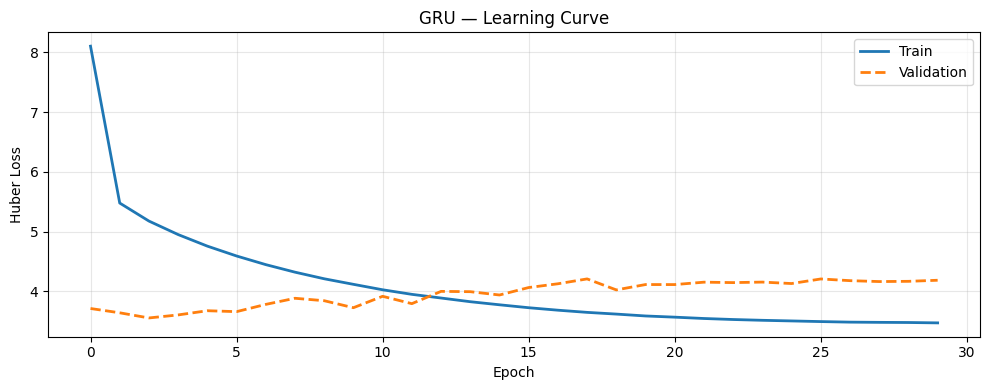

In [22]:
# ─── Courbe d'apprentissage ───────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(train_losses, label="Train", lw=2)
ax.plot(val_losses,   label="Validation", lw=2, linestyle="--")
ax.set(title="GRU — Learning Curve", xlabel="Epoch", ylabel="Huber Loss")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(OUT_DIR / "m7_gru_learning_curve.png", dpi=120, bbox_inches="tight")
plt.show()

In [23]:
# ─── Évaluation GRU sur test ──────────────────────────────────────────────────
gru_model.load_state_dict(torch.load(best_model_path, map_location=DEVICE))
gru_model.eval()

all_preds, all_targets = [], []
with torch.no_grad():
    for X_batch, y_batch in dl_test:
        pred = gru_model(X_batch.to(DEVICE)).cpu().numpy()
        all_preds.append(pred)
        all_targets.append(y_batch.numpy())

all_preds   = np.vstack(all_preds)    # (N_test, 24)
all_targets = np.vstack(all_targets)  # (N_test, 24)

results_gru = []
for i, h in enumerate(HORIZONS):
    y_t = all_targets[:, i]
    y_p = all_preds[:, i]
    mask = y_t > 0
    results_gru.append({
        "Horizon": h,
        "MAE":  round(mean_absolute_error(y_t[mask], y_p[mask]), 3),
        "RMSE": round(rmse(y_t[mask], y_p[mask]), 3),
    })

df_gru = pd.DataFrame(results_gru)

# H1 pour le leaderboard global
mask_h1 = all_targets[:, 0] > 0
RESULTS.append(evaluate("M7 – GRU", all_targets[mask_h1, 0], all_preds[mask_h1, 0]))

display(df_gru)
print(f"\n→ MAE moyen H1–H24 : {df_gru['MAE'].mean():.3f}")

,Horizon,MAE,RMSE
0,1,1.5770,3.0880
1,2,1.7670,3.3570
2,3,1.9430,3.6120
3,4,2.1070,3.8480
4,5,2.2590,4.0690
5,6,2.3930,4.2630
6,7,2.5060,4.4210
7,8,2.6040,4.5620
8,9,2.6950,4.6940
9,10,2.7800,4.8190



→ MAE moyen H1–H24 : 2.768


---
## Comparaison Globale

In [24]:
# ─── Leaderboard H+1 ─────────────────────────────────────────────────────────
df_results = pd.DataFrame(RESULTS).sort_values("MAE")
df_results.index = range(1, len(df_results) + 1)

# Couleur : vert si meilleur, rouge si baseline
print("\n" + "═" * 70)
print("  📊  LEADERBOARD — Horizon H+1 (Test Set)")
print("═" * 70)
display(df_results.style
    .background_gradient(subset=["MAE", "RMSE"], cmap="RdYlGn_r")
    .background_gradient(subset=["R2"], cmap="RdYlGn")
    .format({"MAE": "{:.4f}", "RMSE": "{:.4f}", "SMAPE": "{:.2f}%", "R2": "{:.4f}"})
)

df_results.to_csv(OUT_DIR / "leaderboard_h1.csv", index=False)
print("Saved:", OUT_DIR / "leaderboard_h1.csv")


══════════════════════════════════════════════════════════════════════
  📊  LEADERBOARD — Horizon H+1 (Test Set)
══════════════════════════════════════════════════════════════════════


,Model,MAE,RMSE,SMAPE,R2,N
1,M6 – CatBoost,0.6432,1.3594,6.61%,0.9567,131550
2,M5 – LightGBM,0.6453,1.3254,6.62%,0.9589,131550
3,M1 – Ridge,0.6523,1.1852,6.92%,0.9671,131550
4,M4 – XGBoost,0.6619,1.4999,6.67%,0.9473,131550
5,M2 – Random Forest,0.6768,1.4353,6.99%,0.9518,131550
6,M3 – Extra Trees,0.8807,1.6961,9.41%,0.9327,131550
7,B1 – Persistence,1.2349,2.2005,12.78%,0.8867,131550
8,M7 – GRU,1.5772,3.0884,15.97%,0.7765,130350
9,B2 – Moving Avg 6h,1.9337,3.3235,20.00%,0.7415,131550


Saved: E:\pipeline\test2\modeling_outputs\leaderboard_h1.csv


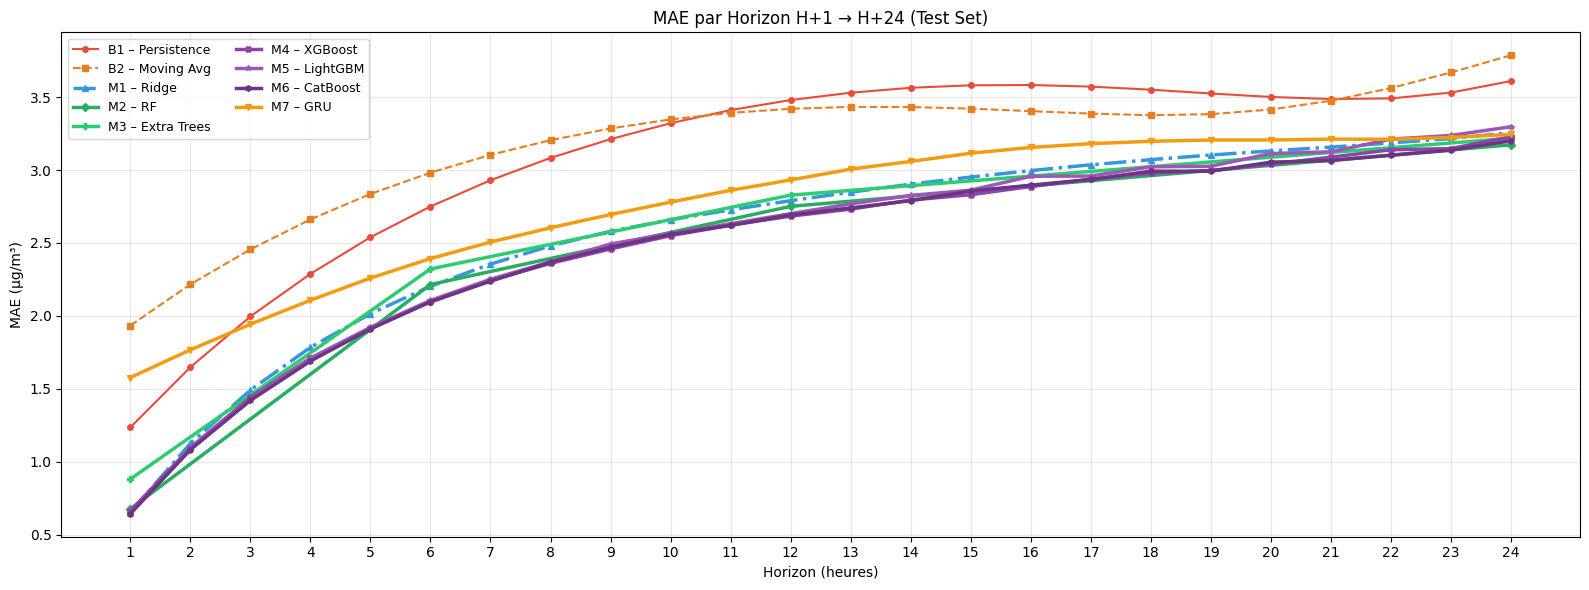

In [25]:
# ─── MAE par horizon (toutes méthodes) ───────────────────────────────────────
horizon_data = {
    "B1 – Persistence": df_persistence.set_index("Horizon")["MAE"],
    "B2 – Moving Avg":  df_ma.set_index("Horizon")["MAE"],
    "M1 – Ridge":       df_lr.set_index("Horizon")["MAE"],
    "M2 – RF":          df_rf.set_index("Horizon")["MAE"],
    "M3 – Extra Trees": df_et.set_index("Horizon")["MAE"],
    "M4 – XGBoost":     df_xgb.set_index("Horizon")["MAE"],
    "M5 – LightGBM":    df_lgb.set_index("Horizon")["MAE"],
    "M6 – CatBoost":    df_cb.set_index("Horizon")["MAE"],
    "M7 – GRU":         df_gru.set_index("Horizon")["MAE"],
}

PALETTE = [
    "#E74C3C", "#E67E22",  # baselines
    "#3498DB",              # LR
    "#27AE60", "#2ECC71",  # forests
    "#8E44AD", "#9B59B6", "#6C3483",  # boosting
    "#F39C12",              # GRU
]

STYLES = ["-", "--", "-.", "-", "-", "-", "-", "-", "-"]
MARKERS = ["o", "s", "^", "D", "P", "X", "*", "h", "v"]

fig, ax = plt.subplots(figsize=(16, 6))

for (name, series), color, style, marker in zip(horizon_data.items(), PALETTE, STYLES, MARKERS):
    lw = 1.5 if name.startswith("B") else 2.5
    ax.plot(series.index, series.values,
            label=name, color=color, lw=lw,
            linestyle=style, marker=marker, markersize=4)

ax.set(title="MAE par Horizon H+1 → H+24 (Test Set)",
       xlabel="Horizon (heures)", ylabel="MAE (µg/m³)")
ax.legend(loc="upper left", fontsize=9, ncol=2)
ax.grid(alpha=0.3)
ax.set_xticks(HORIZONS)

plt.tight_layout()
plt.savefig(OUT_DIR / "comparison_mae_by_horizon.png", dpi=150, bbox_inches="tight")
plt.show()

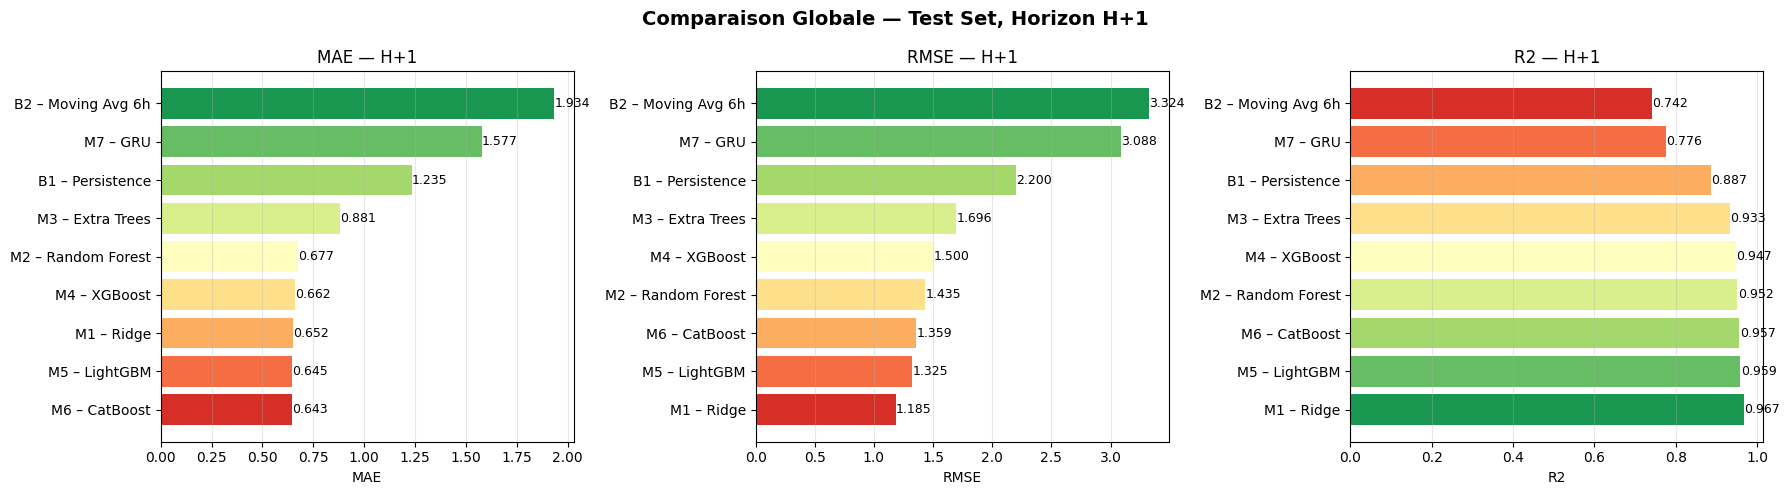

In [26]:
# ─── Barplot MAE / RMSE / R2 (H+1) ──────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, metric, cmap_r in zip(axes,
    ["MAE", "RMSE", "R2"],
    [True, True, False]):

    vals = df_results[["Model", metric]].sort_values(metric, ascending=(not cmap_r))
    colors = sns.color_palette("RdYlGn_r" if cmap_r else "RdYlGn", len(vals))
    bars = ax.barh(vals["Model"], vals[metric], color=colors)

    for bar, v in zip(bars, vals[metric]):
        ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height() / 2,
                f"{v:.3f}", va="center", fontsize=9)

    ax.set(title=f"{metric} — H+1", xlabel=metric)
    ax.grid(axis="x", alpha=0.3)
    ax.invert_yaxis()

plt.suptitle("Comparaison Globale — Test Set, Horizon H+1", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(OUT_DIR / "comparison_barplot_h1.png", dpi=150, bbox_inches="tight")
plt.show()

In [32]:
best_model_name = df_results.iloc[1]["Model"]
print(f"Meilleur modèle : {best_model_name}")

Meilleur modèle : M5 – LightGBM


Meilleur modèle : M5 – LightGBM


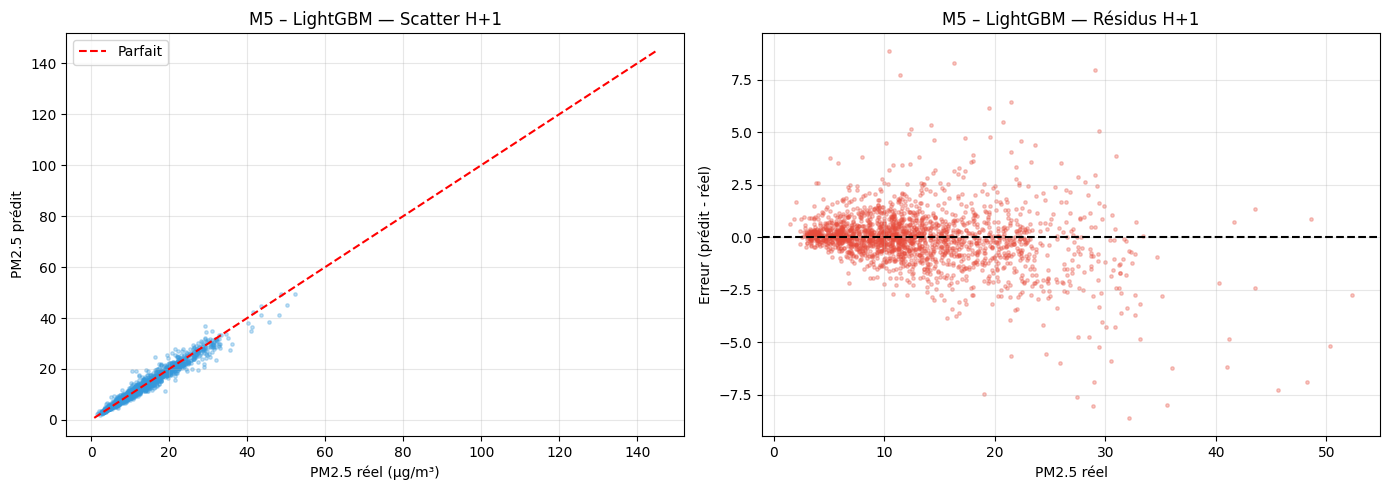

In [33]:
# ─── Scatter : prédictions vs réel (meilleur modèle H+1) ─────────────────────
best_model_name = df_results.iloc[1]["Model"]
print(f"Meilleur modèle : {best_model_name}")

# Récupérer les prédictions du meilleur modèle (LightGBM en général)
# On utilise lgb_h1_preds comme exemple
y_true_plot, y_pred_plot = lgb_h1_preds   # (changer si LightGBM n'est pas le meilleur)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter
ax = axes[0]
ax.scatter(y_true_plot[:2000], y_pred_plot[:2000], alpha=0.3, s=6, color="#3498DB")
lims = [min(y_true_plot.min(), y_pred_plot.min()), max(y_true_plot.max(), y_pred_plot.max())]
ax.plot(lims, lims, "r--", lw=1.5, label="Parfait")
ax.set(title=f"{best_model_name} — Scatter H+1",
       xlabel="PM2.5 réel (µg/m³)", ylabel="PM2.5 prédit")
ax.legend()
ax.grid(alpha=0.3)

# Résidus
ax = axes[1]
residuals = y_pred_plot[:2000] - y_true_plot[:2000]
ax.scatter(y_true_plot[:2000], residuals, alpha=0.3, s=6, color="#E74C3C")
ax.axhline(0, color="black", lw=1.5, linestyle="--")
ax.set(title=f"{best_model_name} — Résidus H+1",
       xlabel="PM2.5 réel", ylabel="Erreur (prédit - réel)")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(OUT_DIR / "best_model_scatter_residuals.png", dpi=150, bbox_inches="tight")
plt.show()

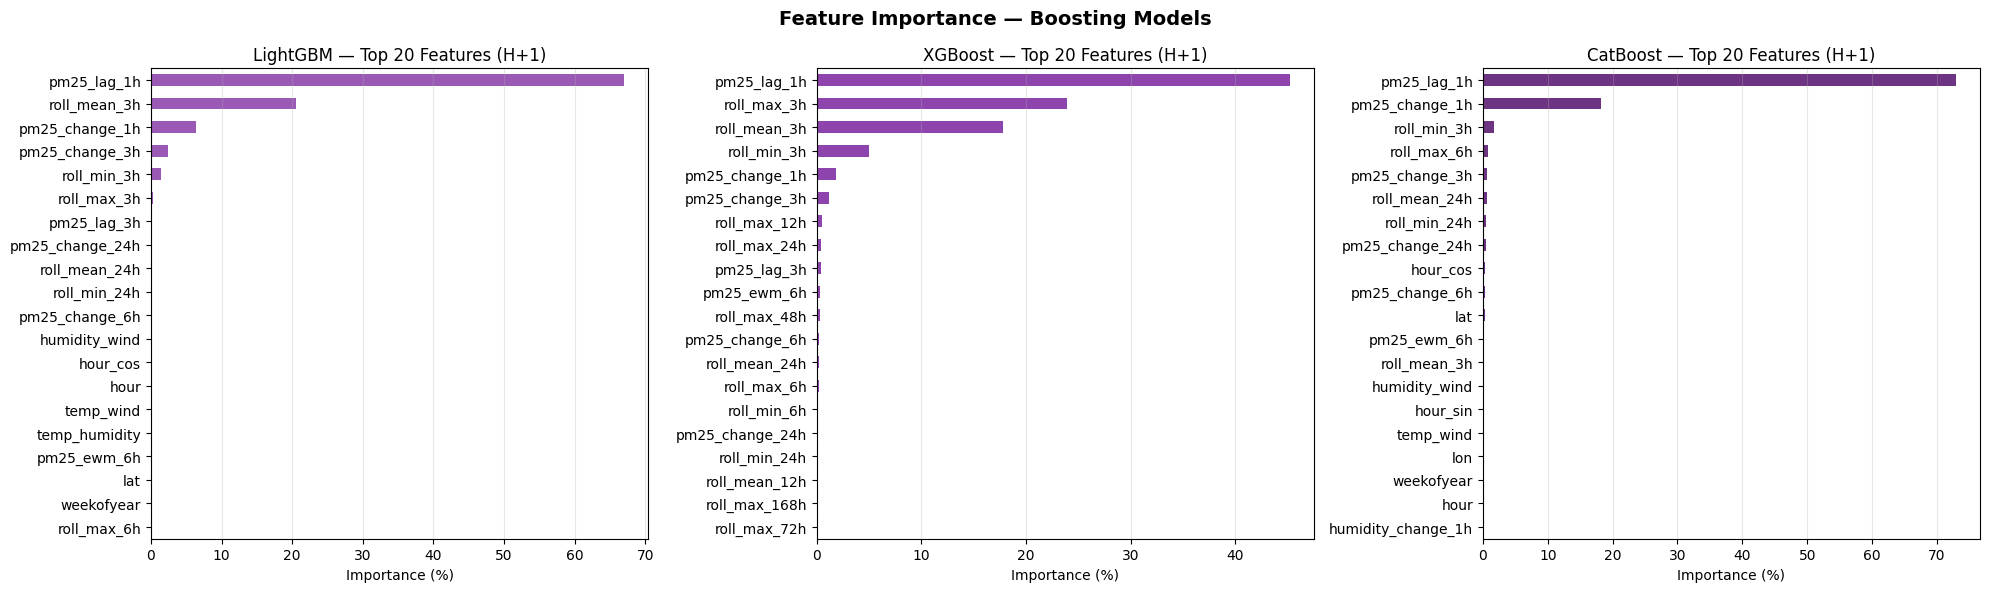

In [34]:
# ─── Feature Importance comparative (LGB vs XGB vs CatBoost) ─────────────────
TOP_N = 20

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for ax, (fi, name, color) in zip(axes, [
    (fi_lgb, "LightGBM", "#9B59B6"),
    (fi_xgb, "XGBoost",  "#8E44AD"),
    (fi_cb,  "CatBoost", "#6C3483"),
]):
    fi_norm = (fi / fi.sum() * 100).head(TOP_N).sort_values()
    fi_norm.plot.barh(ax=ax, color=color)
    ax.set(title=f"{name} — Top {TOP_N} Features (H+1)", xlabel="Importance (%)")
    ax.grid(axis="x", alpha=0.3)

plt.suptitle("Feature Importance — Boosting Models", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(OUT_DIR / "feature_importance_boosting.png", dpi=150, bbox_inches="tight")
plt.show()

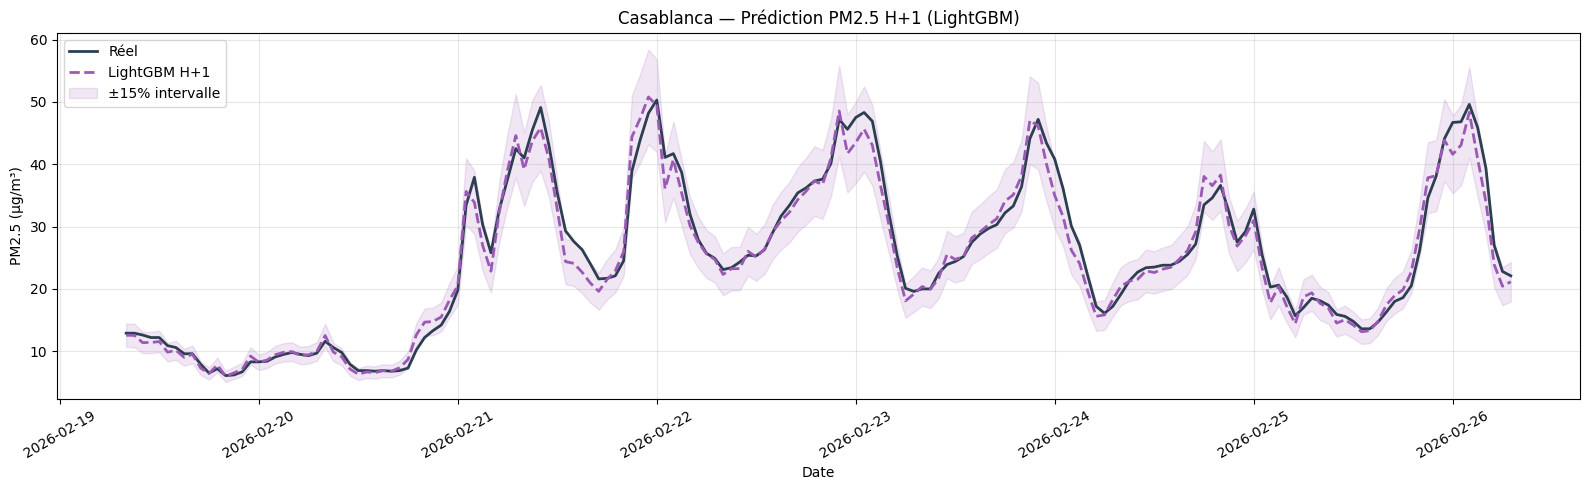

In [35]:
# # ─── Série temporelle : 7 jours d'une ville (meilleur modèle) ────────────────
CITY_DEMO = "Casablanca"
DAYS_DEMO = 7

demo_mask = (df_test["city"] == CITY_DEMO)
df_demo = df_test[demo_mask].sort_values("datetime").head(24 * DAYS_DEMO).copy()

demo_idx = df_test[demo_mask].sort_values("datetime").head(24 * DAYS_DEMO).index

# ── Utiliser FEAT_NUM_LGB (sans city string) ──────────────────────────────────
X_demo = df_test.loc[demo_idx, FEAT_NUM_LGB].astype(float).values.astype(np.float32)

mask_tr_h1 = df_train[TARGET_H1].notna()
mask_va_h1 = df_val[TARGET_H1].notna()

cb_tr = lgb.Dataset(
    df_train.loc[mask_tr_h1, FEAT_NUM_LGB].astype(float).values.astype(np.float32),
    label=df_train.loc[mask_tr_h1, TARGET_H1].values.astype(np.float32),
    free_raw_data=False,
)
cb_va = lgb.Dataset(
    df_val.loc[mask_va_h1, FEAT_NUM_LGB].astype(float).values.astype(np.float32),
    label=df_val.loc[mask_va_h1, TARGET_H1].values.astype(np.float32),
    reference=cb_tr,
    free_raw_data=False,
)

demo_model = lgb.train(
    LGB_PARAMS, cb_tr,
    valid_sets=[cb_va],
    callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(-1)],
)

demo_preds = demo_model.predict(X_demo)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(df_demo["datetime"].values, df_demo["pm2_5"].values,
        label="Réel", color="#2C3E50", lw=2)
ax.plot(df_demo["datetime"].values, demo_preds,
        label="LightGBM H+1", color="#9B59B6", lw=2, linestyle="--")
ax.fill_between(df_demo["datetime"].values,
                demo_preds * 0.85, demo_preds * 1.15,
                alpha=0.15, color="#9B59B6", label="±15% intervalle")
ax.set(title=f"{CITY_DEMO} — Prédiction PM2.5 H+1 (LightGBM)",
       xlabel="Date", ylabel="PM2.5 (µg/m³)")
ax.legend()
ax.grid(alpha=0.3)
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig(OUT_DIR / f"timeseries_{CITY_DEMO.lower()}_lgb_h1.png", dpi=150, bbox_inches="tight")
plt.show()

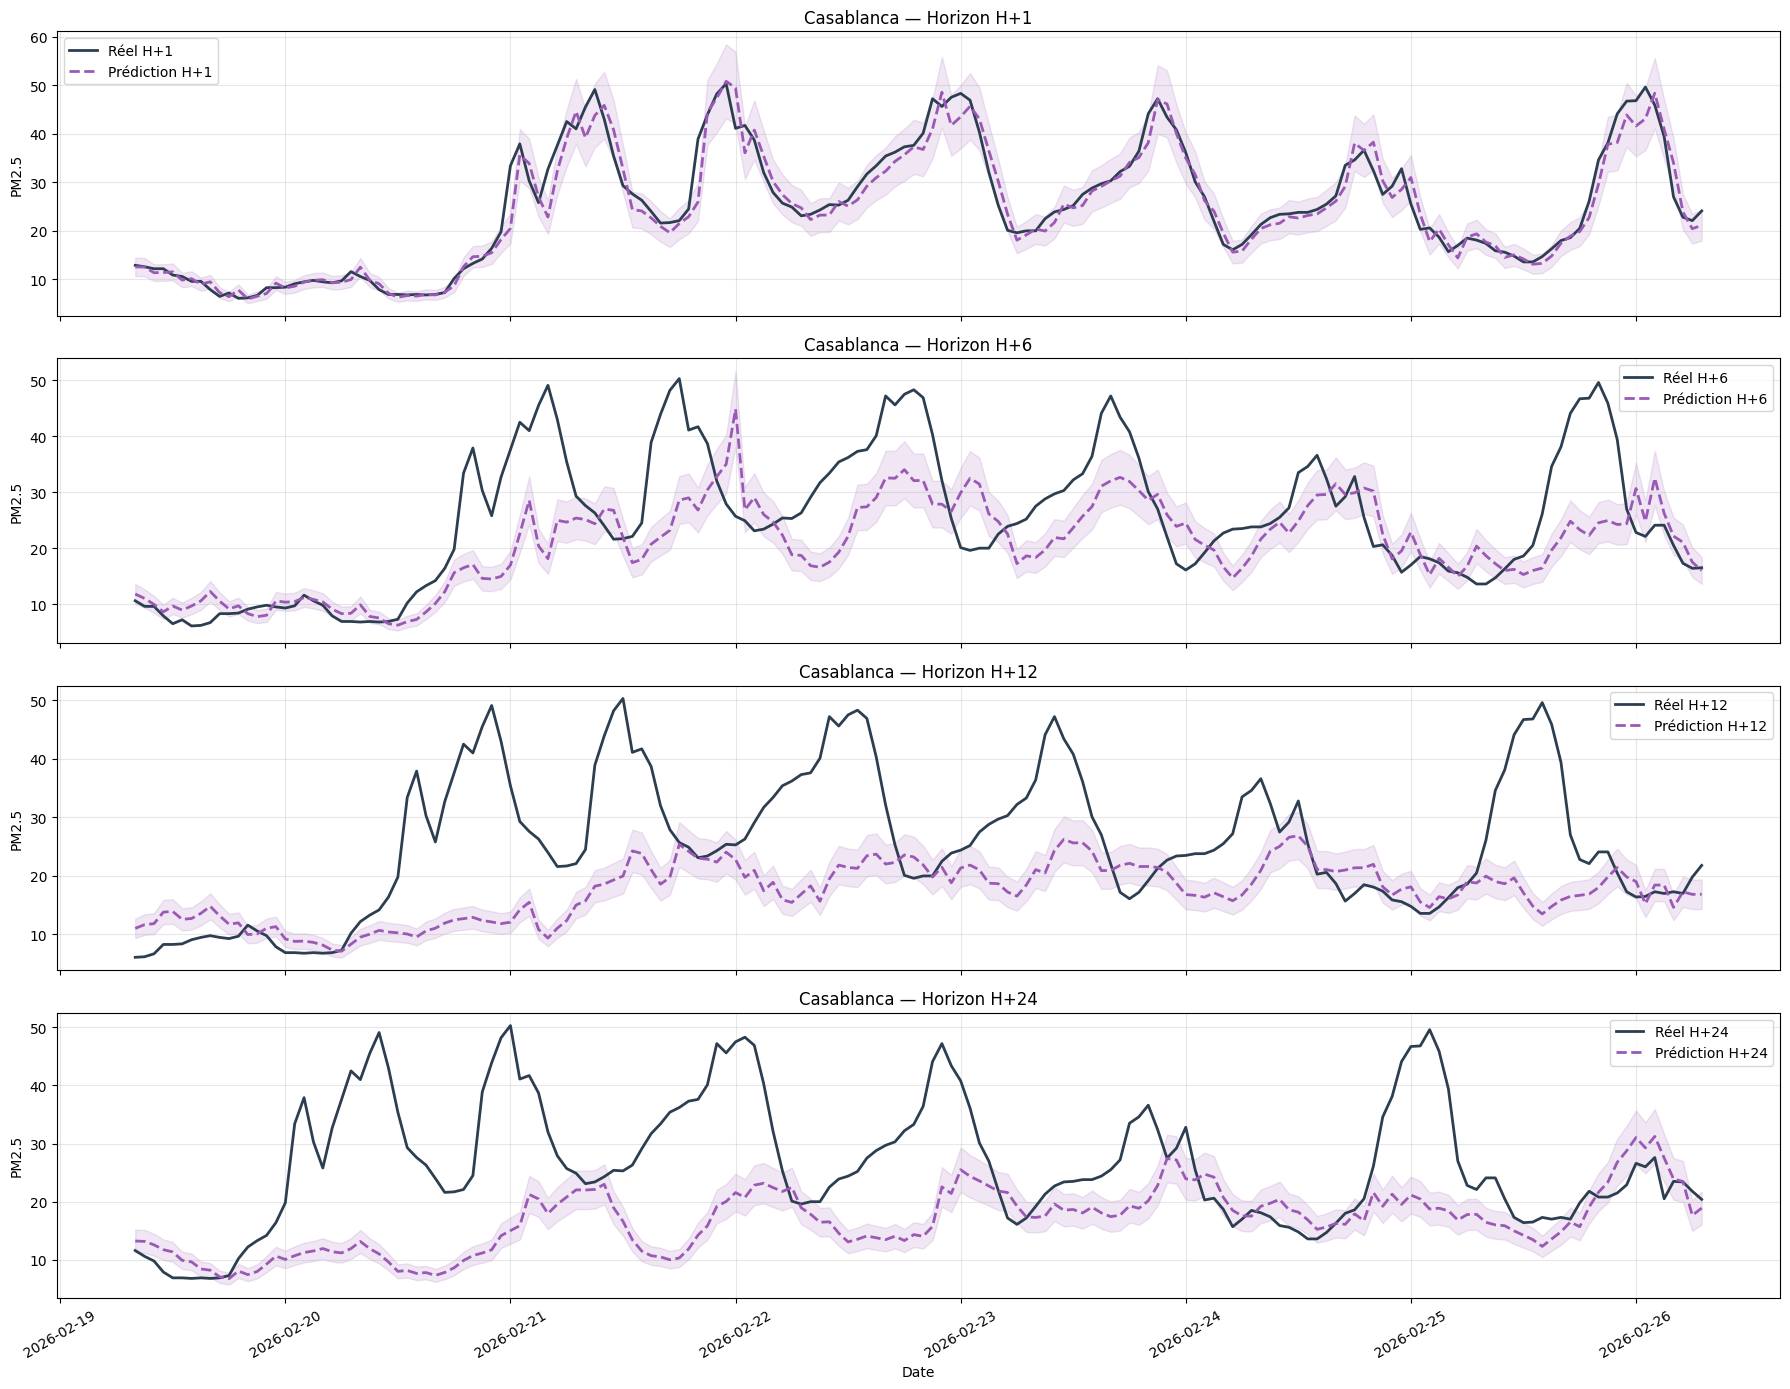

In [38]:
# ─── Série temporelle : 7 jours d'une ville (4 horizons) ─────────────────────

CITY_DEMO = "Casablanca"
DAYS_DEMO = 7
HORIZONS = [1, 6, 12, 24]

demo_mask = (df_test["city"] == CITY_DEMO)

df_demo = (
    df_test[demo_mask]
    .sort_values("datetime")
    .head(24 * DAYS_DEMO)
    .copy()
)

demo_idx = df_demo.index

X_demo = (
    df_test.loc[demo_idx, FEAT_NUM_LGB]
    .astype(float)
    .values
    .astype(np.float32)
)

preds_dict = {}

# ──────────────────────────────────────────────────────────────────────────────
# Entraînement d'un modèle par horizon
# ──────────────────────────────────────────────────────────────────────────────

for h in HORIZONS:

    target_col = f"target24_h{h}"

    mask_tr = df_train[target_col].notna()
    mask_va = df_val[target_col].notna()

    train_set = lgb.Dataset(
        df_train.loc[mask_tr, FEAT_NUM_LGB]
        .astype(float)
        .values
        .astype(np.float32),
        label=df_train.loc[mask_tr, target_col]
        .values
        .astype(np.float32),
        free_raw_data=False,
    )

    valid_set = lgb.Dataset(
        df_val.loc[mask_va, FEAT_NUM_LGB]
        .astype(float)
        .values
        .astype(np.float32),
        label=df_val.loc[mask_va, target_col]
        .values
        .astype(np.float32),
        reference=train_set,
        free_raw_data=False,
    )

    model = lgb.train(
        LGB_PARAMS,
        train_set,
        valid_sets=[valid_set],
        callbacks=[
            lgb.early_stopping(50, verbose=False),
            lgb.log_evaluation(-1)
        ],
    )

    preds_dict[h] = model.predict(X_demo)

# ──────────────────────────────────────────────────────────────────────────────
# Visualisation
# ──────────────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(
    nrows=4,
    ncols=1,
    figsize=(18, 14),
    sharex=True
)

for ax, h in zip(axes, HORIZONS):

    target_col = f"target24_h{h}"

    y_true = df_demo[target_col]

    ax.plot(
        df_demo["datetime"],
        y_true,
        label=f"Réel H+{h}",
        color="#2C3E50",
        linewidth=2
    )

    ax.plot(
        df_demo["datetime"],
        preds_dict[h],
        "--",
        label=f"Prédiction H+{h}",
        color="#9B59B6",
        linewidth=2
    )

    ax.fill_between(
        df_demo["datetime"],
        preds_dict[h] * 0.85,
        preds_dict[h] * 1.15,
        alpha=0.15,
        color="#9B59B6"
    )

    ax.set_ylabel("PM2.5")
    ax.set_title(f"{CITY_DEMO} — Horizon H+{h}")
    ax.grid(alpha=0.3)
    ax.legend()

axes[-1].set_xlabel("Date")

plt.xticks(rotation=30)
plt.tight_layout()

plt.savefig(
    OUT_DIR / f"timeseries_{CITY_DEMO.lower()}_all_horizons.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

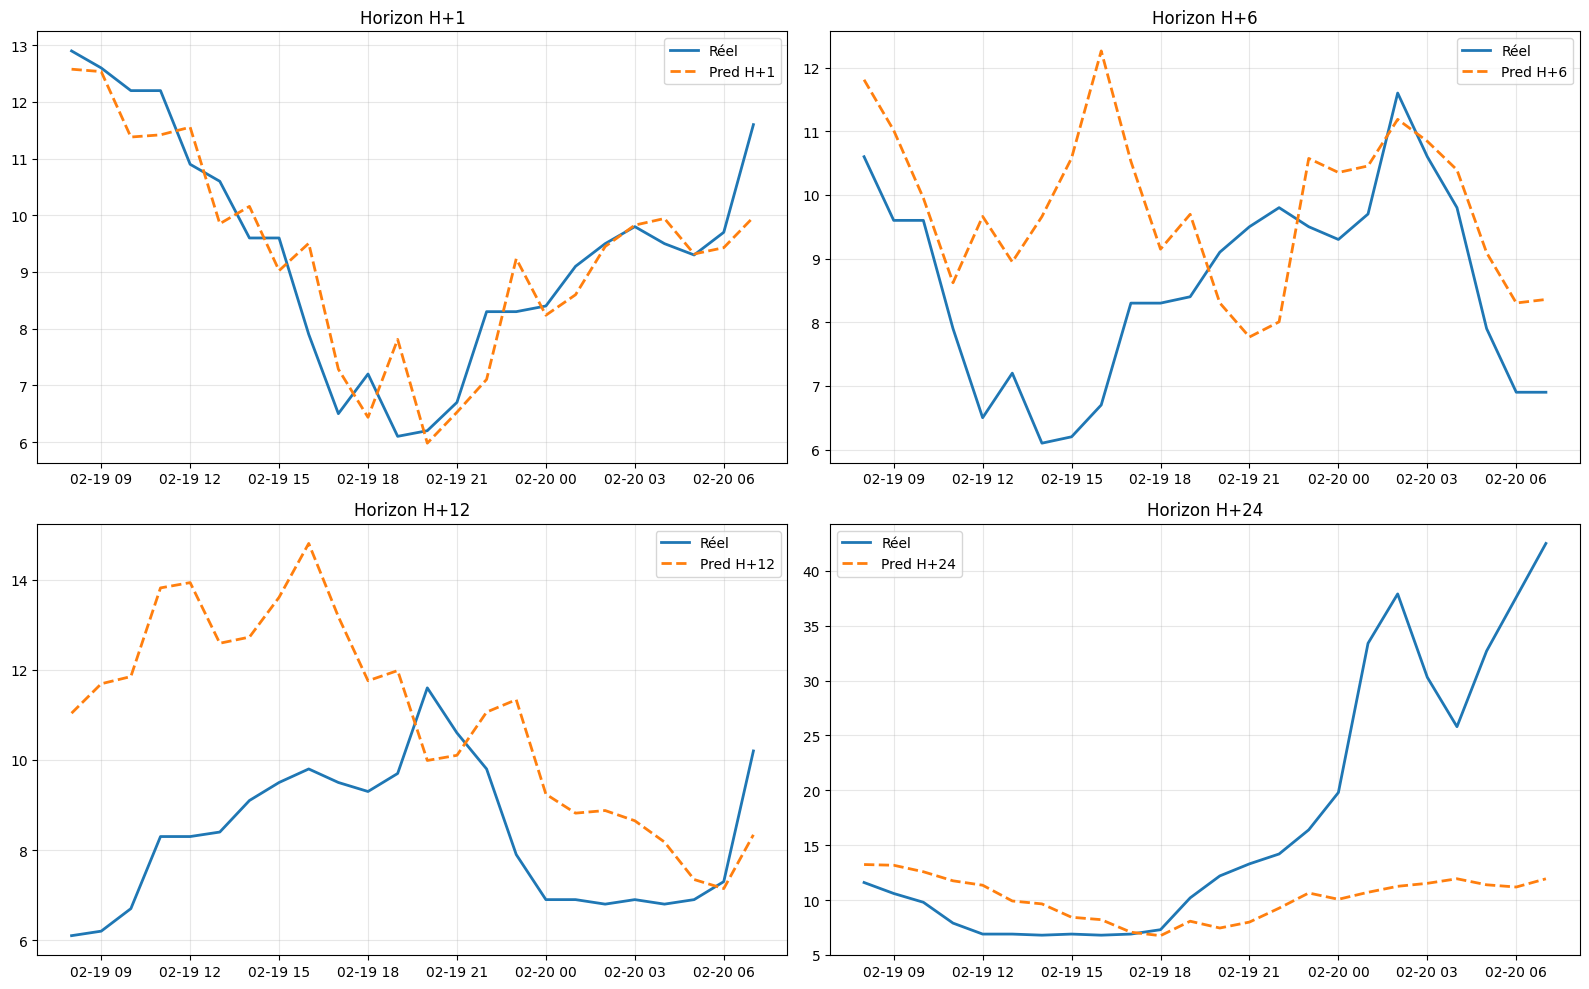

In [39]:
CITY_DEMO = "Casablanca"
HORIZONS = [1, 6, 12, 24]

# Une seule journée
df_demo = (
    df_test[df_test["city"] == CITY_DEMO]
    .sort_values("datetime")
    .head(24)
    .copy()
)

demo_idx = df_demo.index

X_demo = (
    df_demo[FEAT_NUM_LGB]
    .astype(float)
    .values
    .astype(np.float32)
)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

axes = axes.flatten()

for ax, h in zip(axes, HORIZONS):

    target_col = f"target24_h{h}"

    # entraînement modèle horizon h
    mask_tr = df_train[target_col].notna()
    mask_va = df_val[target_col].notna()

    train_set = lgb.Dataset(
        df_train.loc[mask_tr, FEAT_NUM_LGB].astype(float).values.astype(np.float32),
        label=df_train.loc[mask_tr, target_col].values.astype(np.float32),
        free_raw_data=False,
    )

    valid_set = lgb.Dataset(
        df_val.loc[mask_va, FEAT_NUM_LGB].astype(float).values.astype(np.float32),
        label=df_val.loc[mask_va, target_col].values.astype(np.float32),
        reference=train_set,
        free_raw_data=False,
    )

    model = lgb.train(
        LGB_PARAMS,
        train_set,
        valid_sets=[valid_set],
        callbacks=[
            lgb.early_stopping(50, verbose=False),
            lgb.log_evaluation(-1),
        ],
    )

    preds = model.predict(X_demo)

    ax.plot(
        df_demo["datetime"],
        df_demo[target_col],
        label="Réel",
        linewidth=2
    )

    ax.plot(
        df_demo["datetime"],
        preds,
        "--",
        label=f"Pred H+{h}",
        linewidth=2
    )

    ax.set_title(f"Horizon H+{h}")
    ax.grid(alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.show()

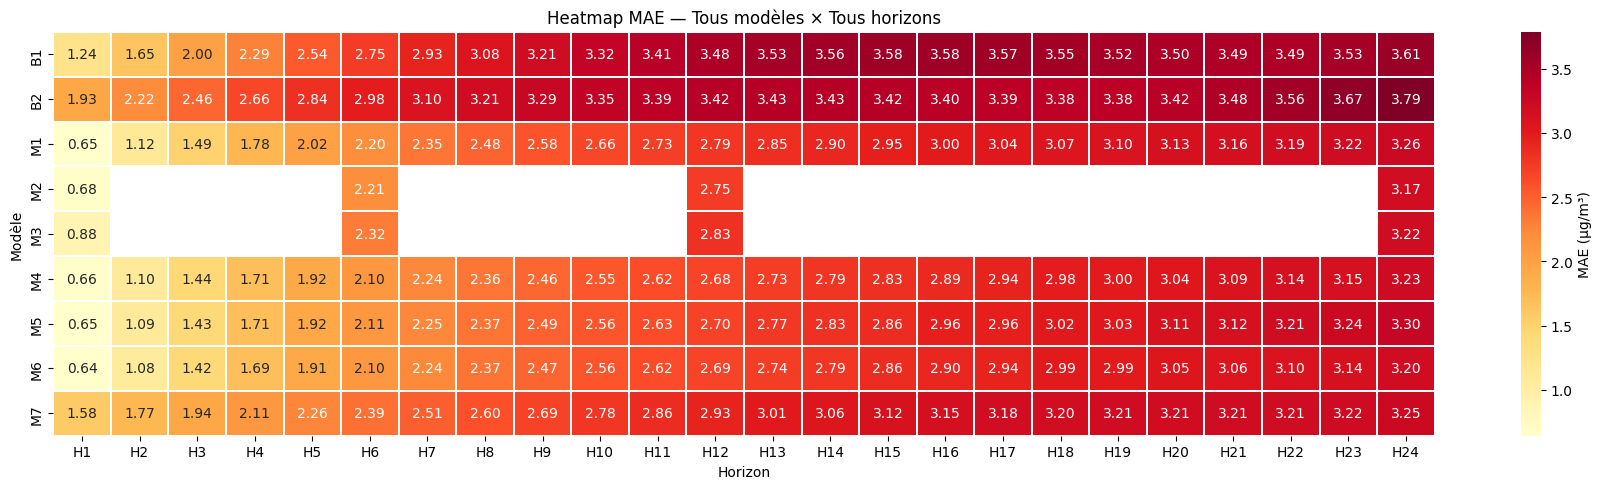

In [36]:
# ─── Heatmap MAE H1–H24 : tous les modèles ───────────────────────────────────
heat_data = pd.DataFrame({
    "B1":  df_persistence.set_index("Horizon")["MAE"],
    "B2":  df_ma.set_index("Horizon")["MAE"],
    "M1":  df_lr.set_index("Horizon")["MAE"],
    "M2":  df_rf.set_index("Horizon")["MAE"],
    "M3":  df_et.set_index("Horizon")["MAE"],
    "M4":  df_xgb.set_index("Horizon")["MAE"],
    "M5":  df_lgb.set_index("Horizon")["MAE"],
    "M6":  df_cb.set_index("Horizon")["MAE"],
    "M7":  df_gru.set_index("Horizon")["MAE"],
}).T

heat_data.columns = [f"H{h}" for h in HORIZONS]

fig, ax = plt.subplots(figsize=(18, 5))
sns.heatmap(
    heat_data, annot=True, fmt=".2f", cmap="YlOrRd",
    linewidths=0.3, ax=ax, cbar_kws={"label": "MAE (µg/m³)"}
)
ax.set(title="Heatmap MAE — Tous modèles × Tous horizons",
       xlabel="Horizon", ylabel="Modèle")
plt.tight_layout()
plt.savefig(OUT_DIR / "heatmap_mae_all_models.png", dpi=150, bbox_inches="tight")
plt.show()

In [37]:
# ─── Résumé final ─────────────────────────────────────────────────────────────
print("\n" + "═" * 65)
print("  🏆  RÉSUMÉ FINAL")
print("═" * 65)

def safe_get(series, pos):
    """Récupère iloc[pos] si existe, sinon NaN."""
    return series.iloc[pos].round(3) if len(series) > pos else np.nan

mean_mae = pd.DataFrame({
    "Modèle":           list(horizon_data.keys()),
    "MAE_mean":         [s.mean().round(3) for s in horizon_data.values()],
    "MAE_H1":           [safe_get(s, 0)  for s in horizon_data.values()],
    "MAE_H12":          [safe_get(s, 11) for s in horizon_data.values()],
    "MAE_H24":          [safe_get(s, 23) for s in horizon_data.values()],
    "N_horizons_eval":  [len(s) for s in horizon_data.values()],
}).sort_values("MAE_mean")

display(mean_mae.style.background_gradient(
    subset=["MAE_mean", "MAE_H1"], cmap="RdYlGn_r"
))

mean_mae.to_csv(OUT_DIR / "final_summary.csv", index=False)
print("\nSaved:", OUT_DIR / "final_summary.csv")
print("Toutes les figures dans:", OUT_DIR)


═════════════════════════════════════════════════════════════════
  🏆  RÉSUMÉ FINAL
═════════════════════════════════════════════════════════════════


,Modèle,MAE_mean,MAE_H1,MAE_H12,MAE_H24,N_horizons_eval
3,M2 – RF,2.204000,0.677000,nan,nan,4
4,M3 – Extra Trees,2.312000,0.881000,nan,nan,4
7,M6 – CatBoost,2.481000,0.643000,2.692000,3.201000,24
5,M4 – XGBoost,2.485000,0.662000,2.684000,3.229000,24
6,M5 – LightGBM,2.513000,0.645000,2.701000,3.297000,24
2,M1 – Ridge,2.572000,0.652000,2.790000,3.256000,24
8,M7 – GRU,2.768000,1.577000,2.932000,3.245000,24
0,B1 – Persistence,3.101000,1.235000,3.480000,3.610000,24
1,B2 – Moving Avg,3.191000,1.934000,3.420000,3.787000,24



Saved: E:\pipeline\test2\modeling_outputs\final_summary.csv
Toutes les figures dans: E:\pipeline\test2\modeling_outputs
